In [1]:
# #place to pip install
# %pip install pandas 
# %pip install numpy
# %pip install seaborn
# %pip install matplotlib 
# %pip install scikit-learn
# # command for checking packages you installed etc.
# !conda list

# # run this to ensure  running within conda environment
# import sys 
# sys.executable

## Data Exploration

In [2]:
#imported libraries
import pandas as pd
import numpy as np
from uwb_dataset import import_from_files
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
dataset = import_from_files('../dataset/')
#load dataset from uwb script provided
df = pd.DataFrame(dataset)
print(f"Dataset shape: {df.shape}")


Processing file: ../dataset/uwb_dataset_part1.csv
Successfully loaded data from ../dataset/uwb_dataset_part1.csv
Processing file: ../dataset/uwb_dataset_part2.csv
Successfully loaded data from ../dataset/uwb_dataset_part2.csv
Processing file: ../dataset/uwb_dataset_part3.csv
Successfully loaded data from ../dataset/uwb_dataset_part3.csv
Processing file: ../dataset/uwb_dataset_part4.csv
Successfully loaded data from ../dataset/uwb_dataset_part4.csv
Processing file: ../dataset/uwb_dataset_part5.csv
Successfully loaded data from ../dataset/uwb_dataset_part5.csv
Processing file: ../dataset/uwb_dataset_part6.csv
Successfully loaded data from ../dataset/uwb_dataset_part6.csv
Processing file: ../dataset/uwb_dataset_part7.csv
Successfully loaded data from ../dataset/uwb_dataset_part7.csv
Successfully processed 7 files
Dataset shape: (42000, 1031)
Dataset shape: (42000, 1031)


In [4]:
#add in the attributes names to the combined dataset from all the csv files and stuff
column_names = [
    'NLOS',              # 1 if NLOS, 0 if LOS
    'measured_range',    # Measured range (time of flight)
    'RXPACC',           # received RX preamble symbols
    'FP_AMP1',          # first path amplitude - part1
    'FP_AMP2',          # first path amplitude - part2
    'FP_AMP3',          # first path amplitude - part3
    'STDEV_NOISE',      # standard deviation of noise
    'CIR_PWR',         # total channel impulse response power
    'MAX_NOISE',        # maximum value of noise
    'FP_IDX',          # first path index
    'CH',              # channel number
    'FRAME_LEN',       # length of frame
    'PREAM_LEN',       # preamble length
    'BITRATE',         # bitrate
    'PRFR'             # pulse repetition frequency rate in MHz
]

#add CIR column names (1016 samples)
cir_columns = [f'CIR_{i}' for i in range(1016)]
column_names.extend(cir_columns)

# rename DataFrame columns
df.columns = column_names

# find dtypes for each attribute
print("=== Data Types Analysis ===")
print("\nFeature Data Types:")

print(df.dtypes.head(15))

print("\n\nFeature describe:")
print(df.describe())

#see if total shape matches
print("\n\n Shape of total combined dataset:")
print("DataFrame shape:", df.shape)

df.head()
 


=== Data Types Analysis ===

Feature Data Types:
NLOS              float64
measured_range    float64
RXPACC            float64
FP_AMP1           float64
FP_AMP2           float64
FP_AMP3           float64
STDEV_NOISE       float64
CIR_PWR           float64
MAX_NOISE         float64
FP_IDX            float64
CH                float64
FRAME_LEN         float64
PREAM_LEN         float64
BITRATE           float64
PRFR              float64
dtype: object


Feature describe:
               NLOS  measured_range        RXPACC       FP_AMP1       FP_AMP2  \
count  42000.000000    42000.000000  42000.000000  42000.000000  42000.000000   
mean       0.500000        3.831519    745.654167   8127.521905  11425.259524   
std        0.500006        2.355976      4.505024   5393.330697   6235.434769   
min        0.000000        0.000000    707.000000      7.000000     63.000000   
25%        0.000000        1.810000    744.000000   3573.750000   5322.750000   
50%        0.500000        3.480000    74

,NLOS,measured_range,RXPACC,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,FP_IDX,...,CIR_1006,CIR_1007,CIR_1008,CIR_1009,CIR_1010,CIR_1011,CIR_1012,CIR_1013,CIR_1014,CIR_1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,154.0,209.0,242.0,296.0,87.0,178.0,314.0,247.0,292.0,256.0


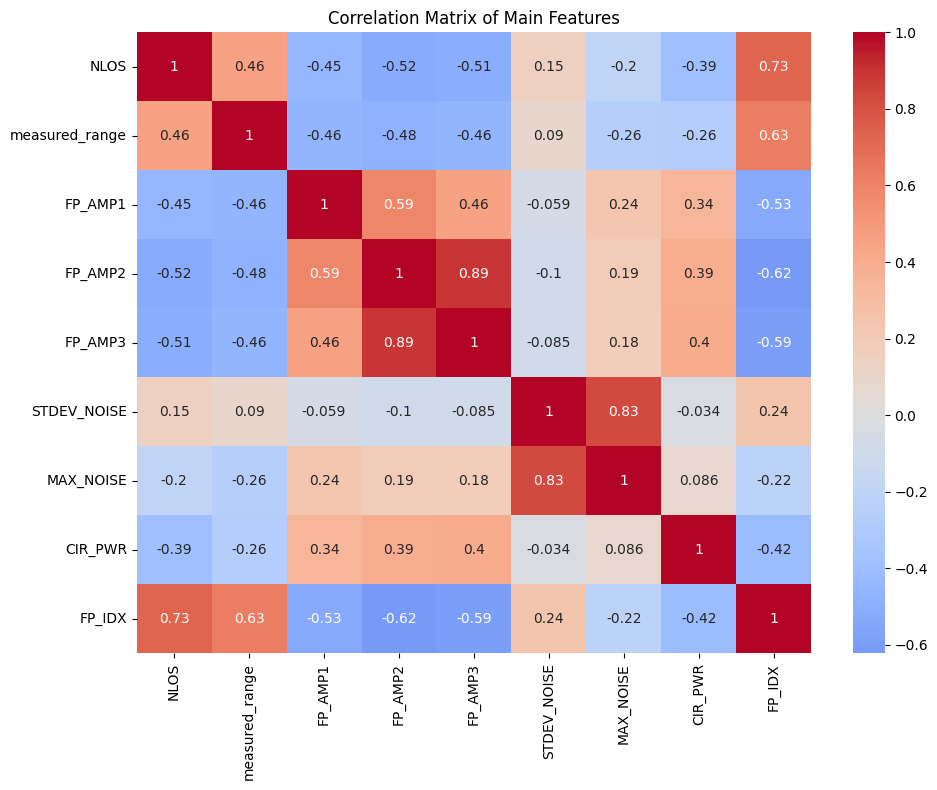

In [5]:
# correlation matrix visualisation (without CIR 1016 columns )

main_features = ['NLOS', 'measured_range', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 
                 'STDEV_NOISE', 'MAX_NOISE', 'CIR_PWR', 'FP_IDX']

# Create correlation matrix for main features
plt.figure(figsize=(10, 8))
correlation = df[main_features].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Main Features')
plt.tight_layout()
plt.show()

In [6]:
#distribution plot
cir_columns = [col for col in df.columns if 'CIR_' in col]

# Calculate summary features
df['CIR_mean'] = df[cir_columns].mean(axis=1)
df['CIR_std'] = df[cir_columns].std(axis=1)
df['CIR_max'] = df[cir_columns].max(axis=1)
df['CIR_energy'] = (df[cir_columns]**2).sum(axis=1)

## Visualisations for aggregation of mean,std,max for all CIR cols

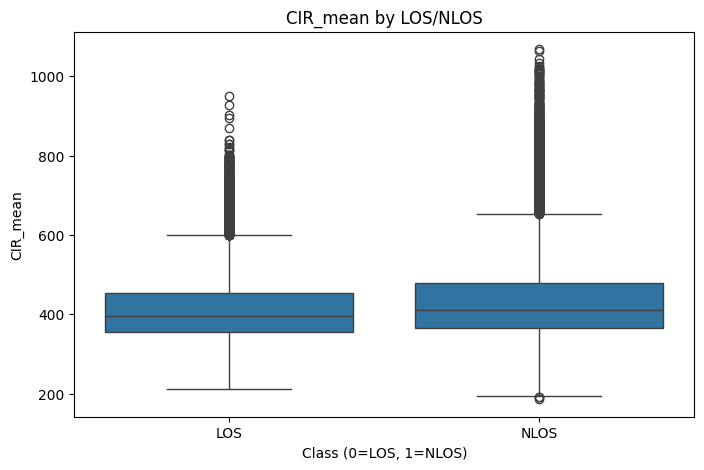

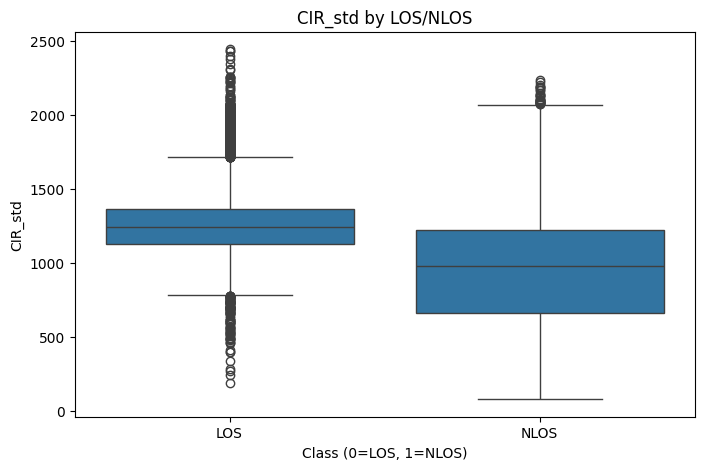

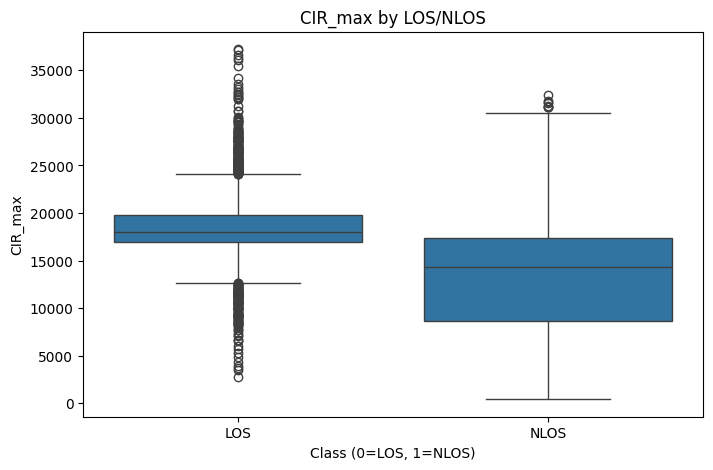

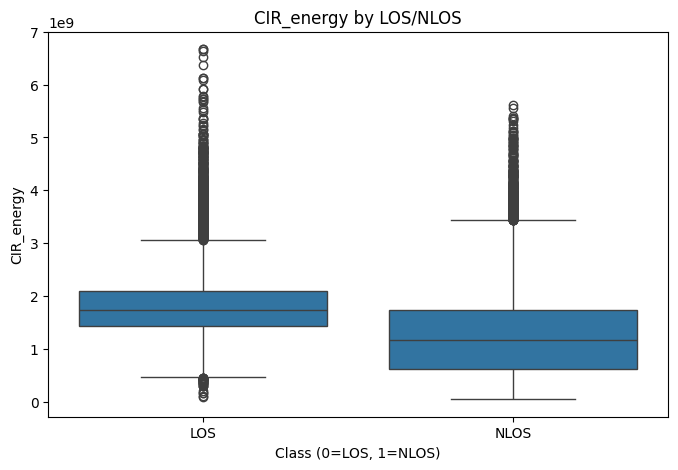

In [7]:
summary_features = ['CIR_mean', 'CIR_std', 'CIR_max', 'CIR_energy']

for feature in summary_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='NLOS', y=feature)
    plt.title(f'{feature} by LOS/NLOS')
    plt.xlabel('Class (0=LOS, 1=NLOS)')
    plt.ylabel(feature)
    plt.xticks([0, 1], ['LOS', 'NLOS'])
    plt.show()

## Visualisations for all other features non-CIR cols

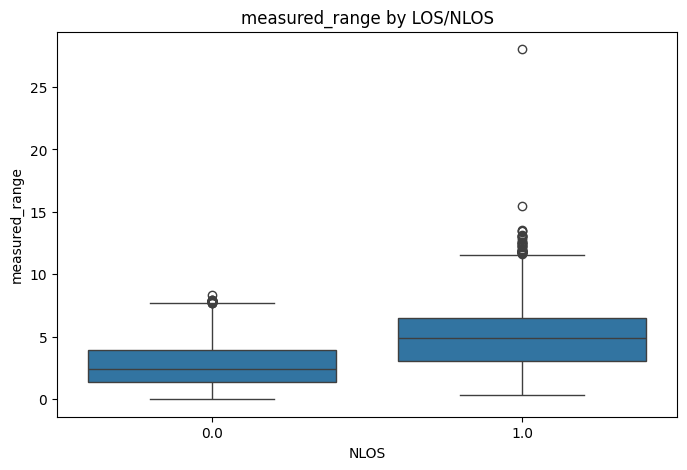

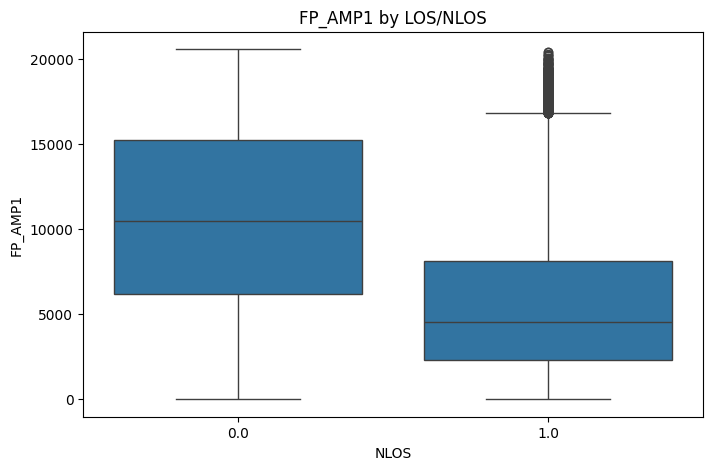

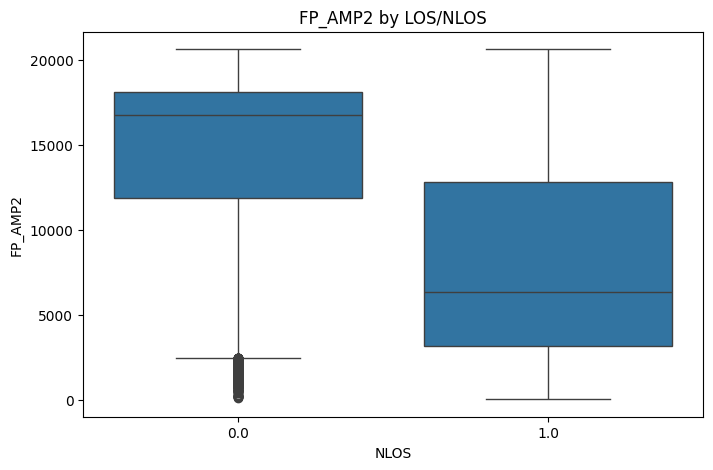

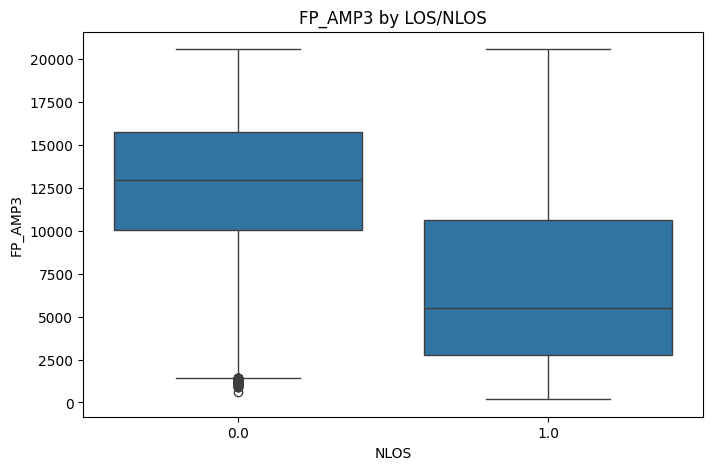

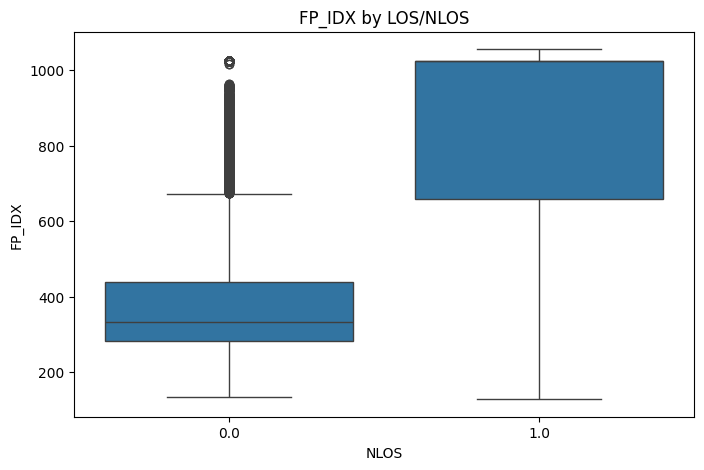

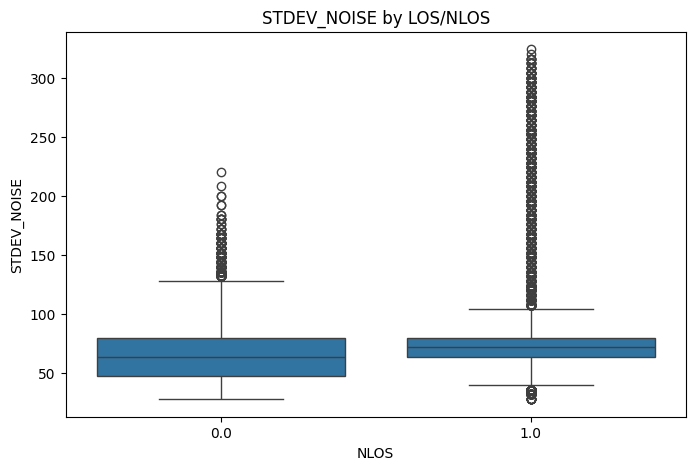

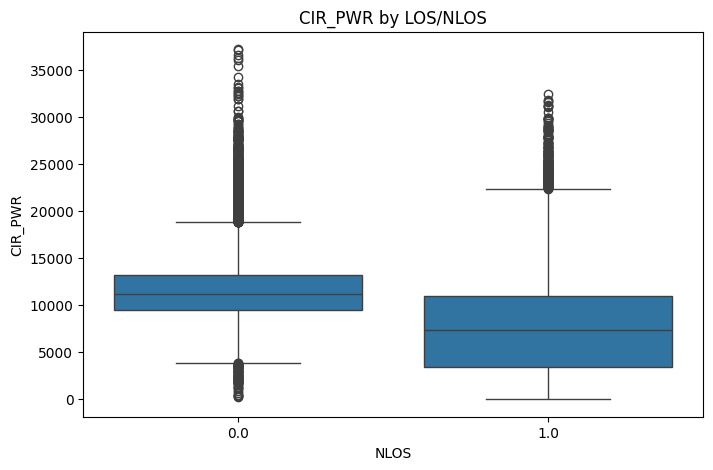

In [8]:
other_features = ['measured_range', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 
                  'FP_IDX', 'STDEV_NOISE', 'CIR_PWR']

for feature in other_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x='NLOS', y=feature)
    plt.title(f'{feature} by LOS/NLOS')
    plt.show()


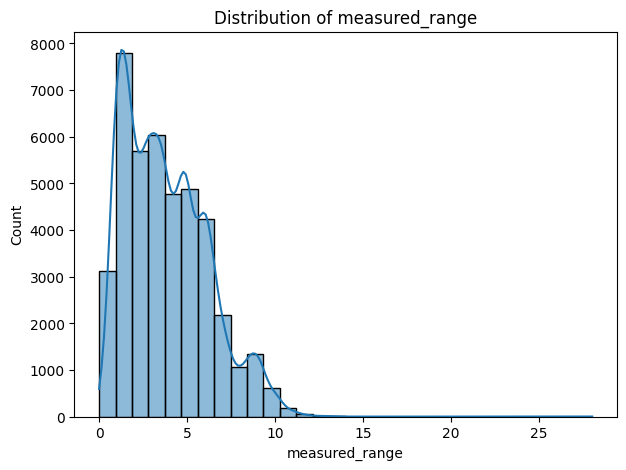

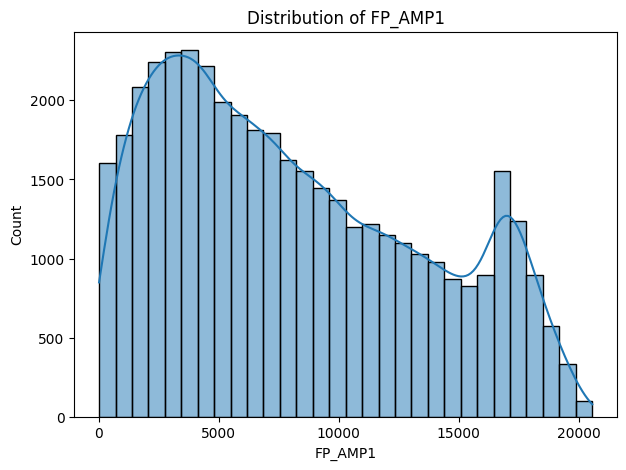

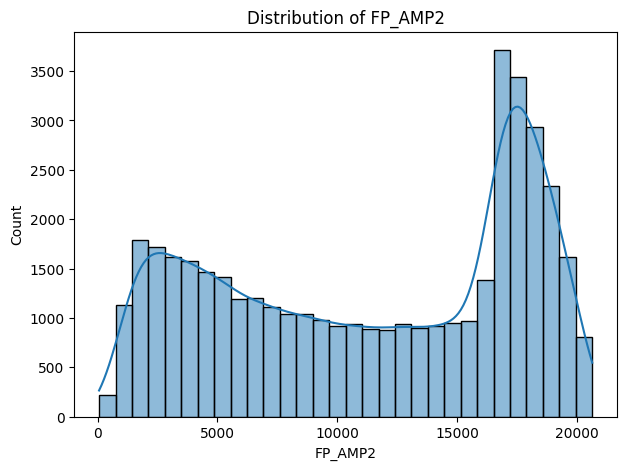

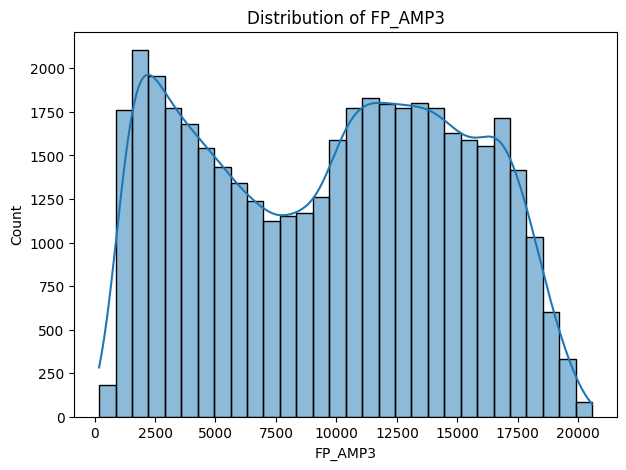

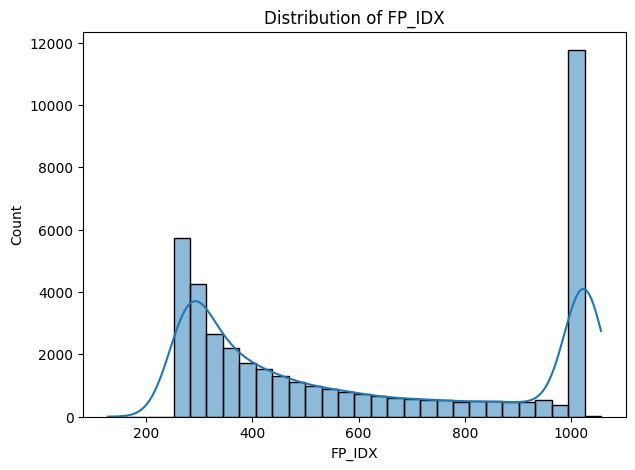

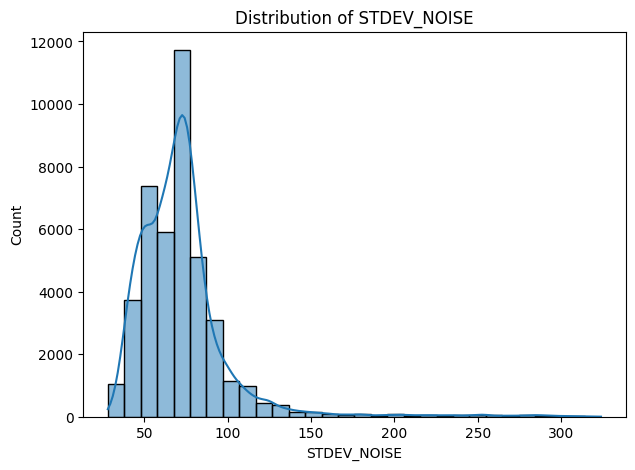

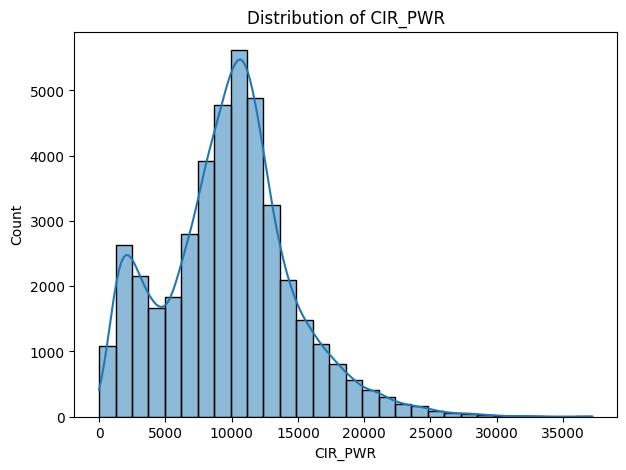

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in other_features:
    plt.figure(figsize=(7,5))
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f"Distribution of {feature}")
    plt.show()


## Data Cleaning

### Missing Values

In [10]:
# check that the categorical data for part 1 is has no other values other than 0/1
print('unique labels in NLOS: ', df['NLOS'].unique())

unique labels in NLOS:  [0. 1.]


In [11]:
# check ensure no missing values within the dataset
print('Number of instances = %d' % (df.shape[0]))
print('Number of attributes = %d' % (df.shape[1]))

print('Number of missing values:')
for col in df.columns:
    print('\t%s: %d' % (col, df[col].isna().sum()))   

Number of instances = 42000
Number of attributes = 1035
Number of missing values:
	NLOS: 0
	measured_range: 0
	RXPACC: 0
	FP_AMP1: 0
	FP_AMP2: 0
	FP_AMP3: 0
	STDEV_NOISE: 0
	CIR_PWR: 0
	MAX_NOISE: 0
	FP_IDX: 0
	CH: 0
	FRAME_LEN: 0
	PREAM_LEN: 0
	BITRATE: 0
	PRFR: 0
	CIR_0: 0
	CIR_1: 0
	CIR_2: 0
	CIR_3: 0
	CIR_4: 0
	CIR_5: 0
	CIR_6: 0
	CIR_7: 0
	CIR_8: 0
	CIR_9: 0
	CIR_10: 0
	CIR_11: 0
	CIR_12: 0
	CIR_13: 0
	CIR_14: 0
	CIR_15: 0
	CIR_16: 0
	CIR_17: 0
	CIR_18: 0
	CIR_19: 0
	CIR_20: 0
	CIR_21: 0
	CIR_22: 0
	CIR_23: 0
	CIR_24: 0
	CIR_25: 0
	CIR_26: 0
	CIR_27: 0
	CIR_28: 0
	CIR_29: 0
	CIR_30: 0
	CIR_31: 0
	CIR_32: 0
	CIR_33: 0
	CIR_34: 0
	CIR_35: 0
	CIR_36: 0
	CIR_37: 0
	CIR_38: 0
	CIR_39: 0
	CIR_40: 0
	CIR_41: 0
	CIR_42: 0
	CIR_43: 0
	CIR_44: 0
	CIR_45: 0
	CIR_46: 0
	CIR_47: 0
	CIR_48: 0
	CIR_49: 0
	CIR_50: 0
	CIR_51: 0
	CIR_52: 0
	CIR_53: 0
	CIR_54: 0
	CIR_55: 0
	CIR_56: 0
	CIR_57: 0
	CIR_58: 0
	CIR_59: 0
	CIR_60: 0
	CIR_61: 0
	CIR_62: 0
	CIR_63: 0
	CIR_64: 0
	CIR_65: 0
	CIR_66: 0
	CIR_67

### different dtype rom what is expected

In [12]:
#check if the values have anything other than numeric float64 basically
for col in df.columns:
    unique_values = df[col].unique()
    print(f"Unique values in {col}: {unique_values[:10]}")  # Show first 10 unique values


Unique values in NLOS: [0. 1.]
Unique values in measured_range: [3.9  0.66 7.86 3.48 1.19 1.27 0.28 1.23 4.99 1.17]
Unique values in RXPACC: [745. 749. 746. 750. 748. 744. 747. 737. 741. 751.]
Unique values in FP_AMP1: [18712. 11239.  4355.  8502. 17845.  3446. 18991. 14781.  4053. 10153.]
Unique values in FP_AMP2: [10250.  6313.  5240.  8416. 18095. 13680. 19444. 10399.  8174.  7675.]
Unique values in FP_AMP3: [11576.  4712.  3478.  5890. 12058. 11955. 18370. 10136.  5404.  6064.]
Unique values in STDEV_NOISE: [ 64.  60.  76.  68.  92. 148.  40. 100. 108.  44.]
Unique values in CIR_PWR: [11855. 18968. 14699.  8748. 11380. 10256. 13006.  8025.  9956. 11466.]
Unique values in MAX_NOISE: [ 967. 1133.  894. 1127. 1744. 1397. 3904. 1035. 1485. 2487.]
Unique values in FP_IDX: [ 611.  447.  723. 1024.  276.  600.  283.  272.  301.  278.]
Unique values in CH: [2.]
Unique values in FRAME_LEN: [39. 27. 29.]
Unique values in PREAM_LEN: [1024. 1536.]
Unique values in BITRATE: [110.]
Unique values

### check for dups

In [13]:
dups = df.duplicated()
dups

0        False
1        False
2        False
3        False
4        False
         ...  
41995    False
41996    False
41997    False
41998    False
41999    False
Length: 42000, dtype: bool

In [14]:
duplicate = df[df.duplicated()]
duplicate

,NLOS,measured_range,RXPACC,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,FP_IDX,...,CIR_1010,CIR_1011,CIR_1012,CIR_1013,CIR_1014,CIR_1015,CIR_mean,CIR_std,CIR_max,CIR_energy


### checking for unequal distribution of target variable

Number of LOS samples: 21000
Number of NLOS samples: 21000


C:\Users\Jeung Hong\AppData\Local\Temp\ipykernel_33140\159130609.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=los_nlos_counts.index, y=los_nlos_counts.values, palette='coolwarm')


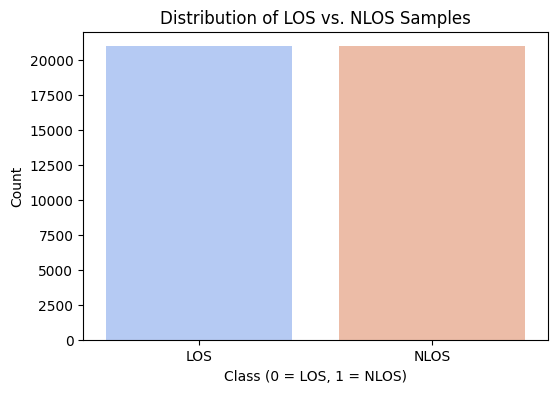

In [15]:
# Count occurrences of each class (assuming 'NLOS' is the column representing LOS/NLOS)
los_nlos_counts = df['NLOS'].value_counts()

# Print the counts
print("Number of LOS samples:", los_nlos_counts[0])  # LOS (0)
print("Number of NLOS samples:", los_nlos_counts[1])  # NLOS (1)

# Optional: Plot the class distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x=los_nlos_counts.index, y=los_nlos_counts.values, palette='coolwarm')
plt.xlabel("Class (0 = LOS, 1 = NLOS)")
plt.ylabel("Count")
plt.title("Distribution of LOS vs. NLOS Samples")
plt.xticks([0, 1], ["LOS", "NLOS"])
plt.show()


In [16]:
column_names = df.columns.tolist()
print("Column names:")
for name in column_names:
    print(name)

Column names:
NLOS
measured_range
RXPACC
FP_AMP1
FP_AMP2
FP_AMP3
STDEV_NOISE
CIR_PWR
MAX_NOISE
FP_IDX
CH
FRAME_LEN
PREAM_LEN
BITRATE
PRFR
CIR_0
CIR_1
CIR_2
CIR_3
CIR_4
CIR_5
CIR_6
CIR_7
CIR_8
CIR_9
CIR_10
CIR_11
CIR_12
CIR_13
CIR_14
CIR_15
CIR_16
CIR_17
CIR_18
CIR_19
CIR_20
CIR_21
CIR_22
CIR_23
CIR_24
CIR_25
CIR_26
CIR_27
CIR_28
CIR_29
CIR_30
CIR_31
CIR_32
CIR_33
CIR_34
CIR_35
CIR_36
CIR_37
CIR_38
CIR_39
CIR_40
CIR_41
CIR_42
CIR_43
CIR_44
CIR_45
CIR_46
CIR_47
CIR_48
CIR_49
CIR_50
CIR_51
CIR_52
CIR_53
CIR_54
CIR_55
CIR_56
CIR_57
CIR_58
CIR_59
CIR_60
CIR_61
CIR_62
CIR_63
CIR_64
CIR_65
CIR_66
CIR_67
CIR_68
CIR_69
CIR_70
CIR_71
CIR_72
CIR_73
CIR_74
CIR_75
CIR_76
CIR_77
CIR_78
CIR_79
CIR_80
CIR_81
CIR_82
CIR_83
CIR_84
CIR_85
CIR_86
CIR_87
CIR_88
CIR_89
CIR_90
CIR_91
CIR_92
CIR_93
CIR_94
CIR_95
CIR_96
CIR_97
CIR_98
CIR_99
CIR_100
CIR_101
CIR_102
CIR_103
CIR_104
CIR_105
CIR_106
CIR_107
CIR_108
CIR_109
CIR_110
CIR_111
CIR_112
CIR_113
CIR_114
CIR_115
CIR_116
CIR_117
CIR_118
CIR_119
CIR_120
CIR_

In [17]:
# Define features to check for outliers (Exclude CIR)
outlier_features = ['measured_range', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE']

# Calculate IQR for each feature
Q1 = df[outlier_features].quantile(0.25)
Q3 = df[outlier_features].quantile(0.75)
IQR = Q3 - Q1

# Determine the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out rows where any feature value is outside the bounds
df_cleaned = df[~((df[outlier_features] < lower_bound) | (df[outlier_features] > upper_bound)).any(axis=1)]

# Print the shape of the dataset before and after removing outliers
print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after outlier removal: {df_cleaned.shape}")

Original dataset shape: (42000, 1035)
Dataset shape after outlier removal: (37605, 1035)


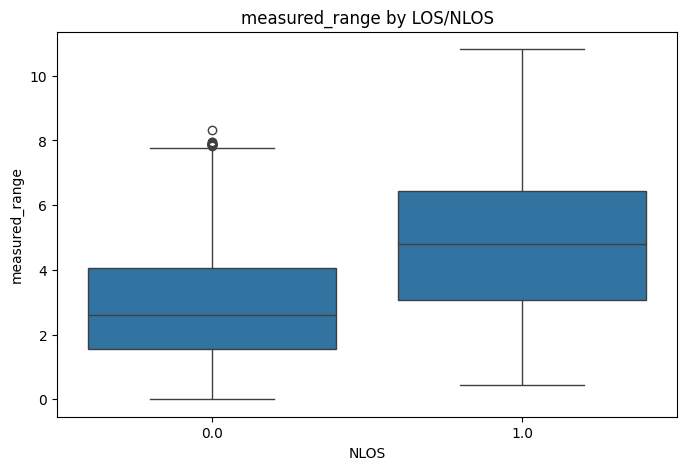

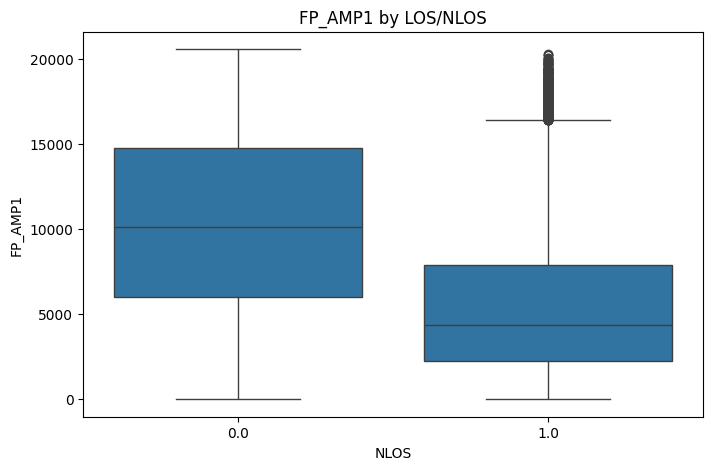

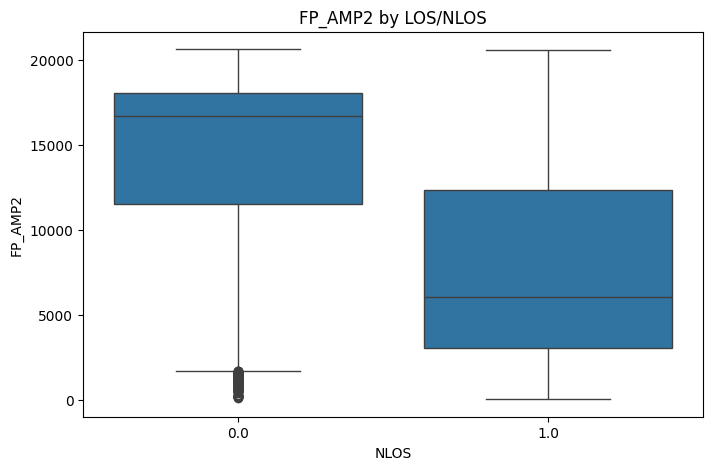

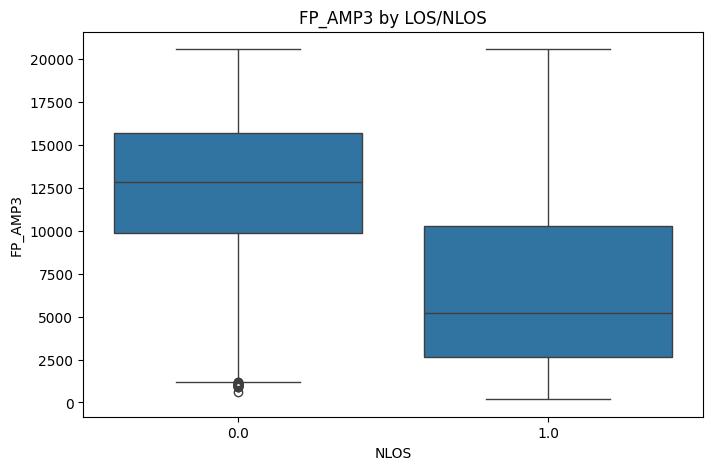

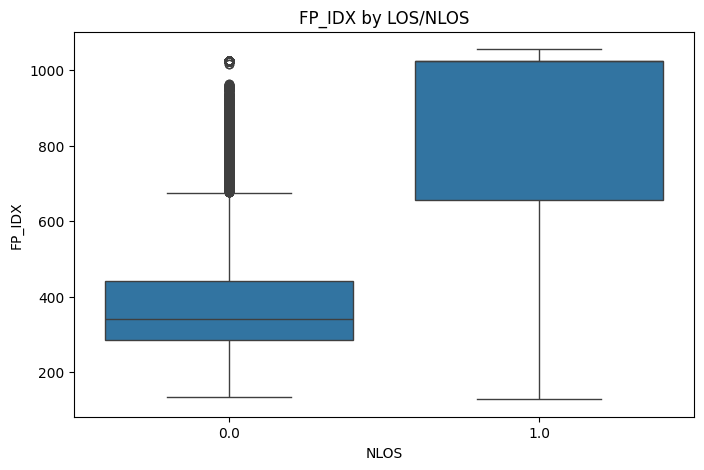

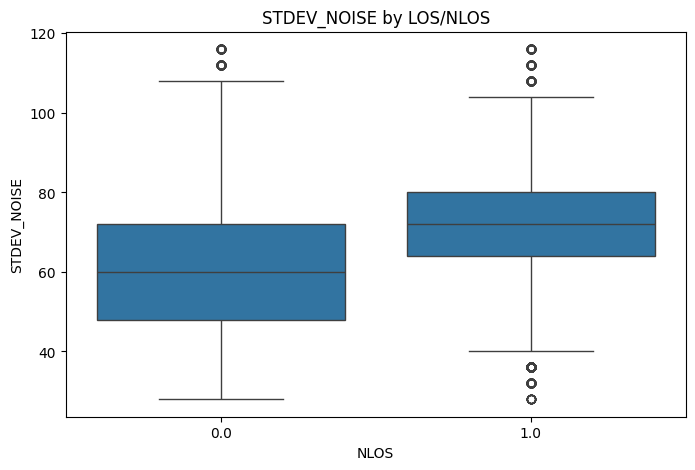

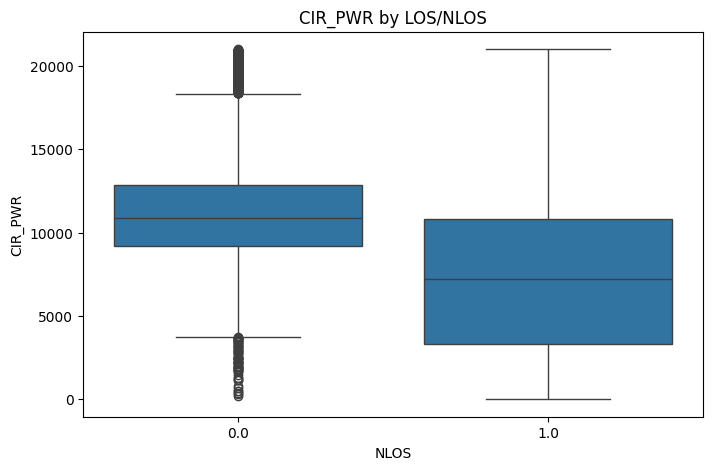

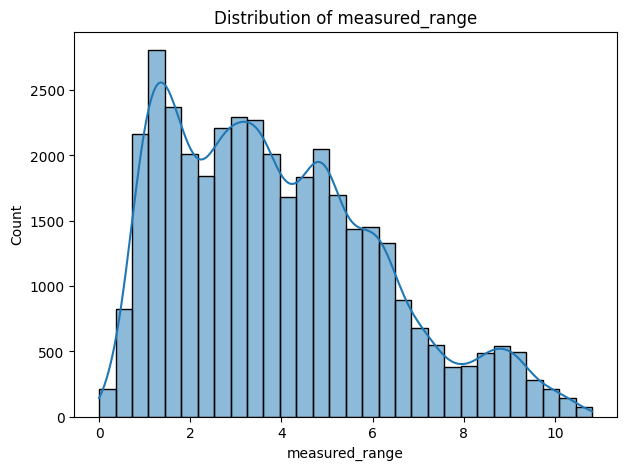

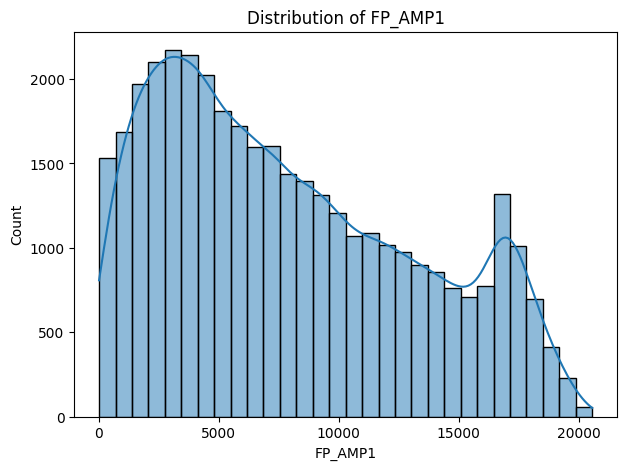

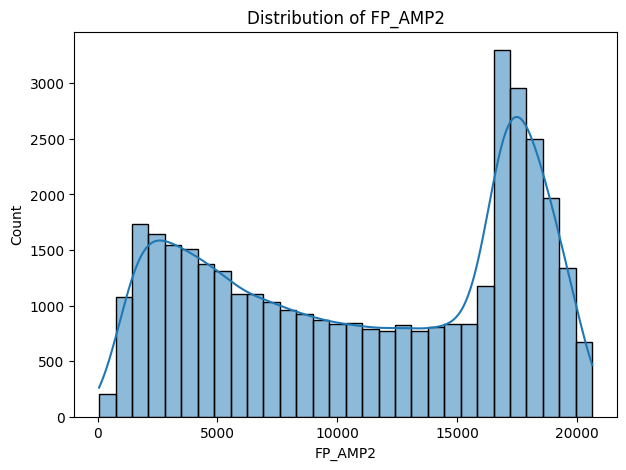

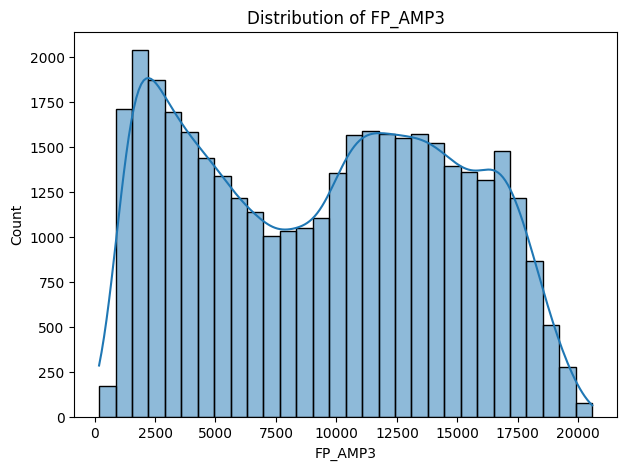

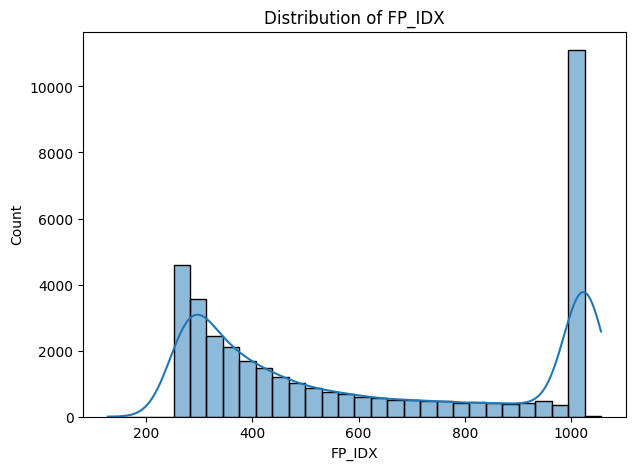

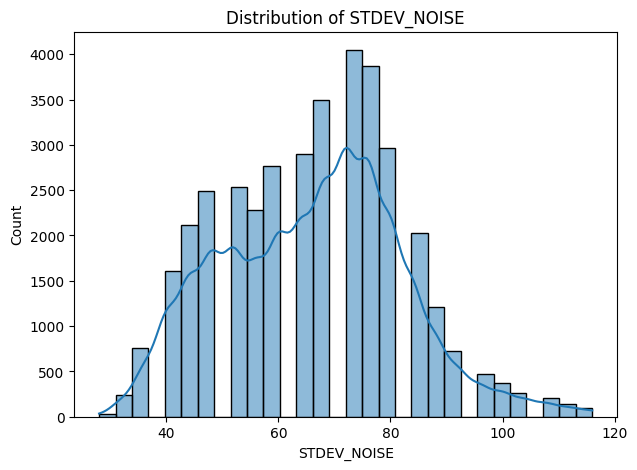

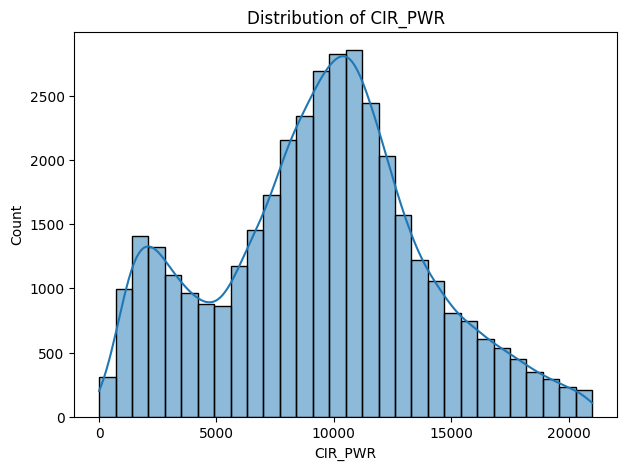

In [18]:
other_features = ['measured_range', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 
                  'FP_IDX', 'STDEV_NOISE', 'CIR_PWR']

for feature in other_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_cleaned, x='NLOS', y=feature)
    plt.title(f'{feature} by LOS/NLOS')
    plt.show()


import seaborn as sns
import matplotlib.pyplot as plt

for feature in other_features:
    plt.figure(figsize=(7,5))
    sns.histplot(df_cleaned[feature], kde=True, bins=30)
    plt.title(f"Distribution of {feature}")
    plt.show()



## Principal Component Analysis (PCA)

In [19]:
#cir_columns already defined earlier in my previous code above in the preprocessing portion

scaler = StandardScaler()
cir_columns_scaled = scaler.fit_transform(df[cir_columns])

#PCA 
dimensions_reducedto = 5
pca = PCA(n_components=dimensions_reducedto)
pca.fit(cir_columns_scaled)
cir_pca = pca.transform(cir_columns_scaled)

# Create a DataFrame for the PCA components
pca_columns = [f'PC{i+1}' for i in range(dimensions_reducedto)]
df_pca = pd.DataFrame(cir_pca, columns=pca_columns)

# Integrate the PCA components back into the original DataFrame
df_cleaned_pca = pd.concat([df, df_pca], axis=1)

# Print the shape of the dataset after adding PCA components
print(f"Dataset shape after adding PCA components: {df_cleaned_pca.shape}")

Dataset shape after adding PCA components: (42000, 1040)


In [20]:
# # Fourth cell - Data Exploration and Analysis
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler

# # 1. Data Types Analysis
# print("=== Data Types Analysis ===")
# print("\nFeature Data Types:")
# print(df.dtypes.head(15))  # Show first 15 non-CIR features

# # 2. Feature Categories for Different Models
# print("\n=== Feature Sets for Models ===")

# # Classification features (LOS/NLOS prediction)
# classification_features = {
#     'signal_strength': ['FP_AMP1', 'FP_AMP2', 'FP_AMP3'],
#     'noise_features': ['STDEV_NOISE', 'MAX_NOISE'],
#     'channel_features': ['CIR_PWR', 'FP_IDX'],
#     'timing_features': ['RXPACC'],
#     'config_features': ['CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR']
# }

# # Regression features (distance estimation)
# regression_features = {
#     'primary_features': ['measured_range', 'RXPACC', 'FP_IDX'],
#     'signal_features': ['FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'CIR_PWR'],
#     'noise_features': ['STDEV_NOISE', 'MAX_NOISE']
# }

# # 3. Basic Statistics
# print("\n=== Basic Statistics for Key Features ===")
# print(df[list(classification_features['signal_strength'] + 
#              classification_features['noise_features'])].describe())

# # 4. Class Distribution
# plt.figure(figsize=(10, 5))
# sns.countplot(data=df, x='NLOS')
# plt.title('Distribution of LOS vs NLOS Samples')
# plt.show()

# # 5. Correlation Analysis
# main_features = ['NLOS', 'measured_range'] + \
#                 classification_features['signal_strength'] + \
#                 classification_features['noise_features'] + \
#                 classification_features['channel_features']

# plt.figure(figsize=(12, 10))
# correlation = df[main_features].corr()
# sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
# plt.title('Correlation Matrix of Main Features')
# plt.tight_layout()
# plt.show()

# # 6. Feature Distributions by Class
# fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# fig.suptitle('Feature Distributions by LOS/NLOS', fontsize=16)

# # Signal strength features
# sns.boxplot(data=df, x='NLOS', y='FP_AMP1', ax=axes[0,0])
# axes[0,0].set_title('First Path Amplitude 1')

# # Noise features
# sns.boxplot(data=df, x='NLOS', y='STDEV_NOISE', ax=axes[0,1])
# axes[0,1].set_title('Standard Deviation of Noise')

# # Channel power
# sns.boxplot(data=df, x='NLOS', y='CIR_PWR', ax=axes[1,0])
# axes[1,0].set_title('Channel Impulse Response Power')

# # Range distribution
# sns.boxplot(data=df, x='NLOS', y='measured_range', ax=axes[1,1])
# axes[1,1].set_title('Measured Range Distribution')

# plt.tight_layout()
# plt.show()

# # 7. Statistical Tests
# from scipy import stats

# print("\n=== Statistical Tests ===")
# for feature in main_features[2:]:  # Excluding NLOS and measured_range
#     los_data = df[df['NLOS'] == 0][feature]
#     nlos_data = df[df['NLOS'] == 1][feature]
#     stat, p_value = stats.mannwhitneyu(los_data, nlos_data)
#     print(f"{feature}: Mann-Whitney U test p-value: {p_value:.10f}")

# # 8. CIR Analysis
# print("\n=== CIR Analysis ===")
# cir_cols = [col for col in df.columns if col.startswith('CIR_')]
# cir_mean = df[cir_cols].mean()
# cir_std = df[cir_cols].std()

# plt.figure(figsize=(15, 5))
# plt.plot(cir_mean, label='Mean CIR')
# plt.fill_between(range(len(cir_mean)), 
#                  cir_mean - cir_std, 
#                  cir_mean + cir_std, 
#                  alpha=0.2)
# plt.title('Average Channel Impulse Response with Standard Deviation')
# plt.xlabel('Sample Index')
# plt.ylabel('Amplitude')
# plt.legend()
# plt.show()

# # 9. Feature Importance Hints
# print("\n=== Feature Importance Hints ===")
# print("Classification Task (LOS/NLOS):")
# for category, features in classification_features.items():
#     correlations = df[features].corrwith(df['NLOS']).abs()
#     print(f"\n{category}:")
#     print(correlations.sort_values(ascending=False))

# print("\nRegression Task (Range Estimation):")
# for category, features in regression_features.items():
#     if 'measured_range' in features:
#         features.remove('measured_range')
#     correlations = df[features].corrwith(df['measured_range']).abs()
#     print(f"\n{category}:")
#     print(correlations.sort_values(ascending=False))
